3. Model Selection 

In this notebook we will look at different models and compare there performance.

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
from data.dataset import Dataset
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt

from models.random_guessing_benchmark import RandomGuessingBenchmark
from evaluation.evaluation_metrics import EvaluationMetrics
from models.cnn_builder import CNNBuilder
from models.training_callbacks import default_callbacks 

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.1 Get and prepare Data

Here I load the data from disk and we first normalize the image arrays, in order to have smaller input values for the neural network, for better training. I also split the data into training, validation and test set. The data will be split in 70% training, 15% validation and 15% test data. 

In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 1750 samples
Validation set: 375 samples
Test set: 375 samples
Input shape: (168, 120, 3)
Number of classes: 5


3.2 Benchmark: Random Guessing

With our 5 balanced classes, random guessing should give ~20% accuracy. This benchmark should act as our lower bound and our model should be able to be better than that.


In [3]:
random_benchmark = RandomGuessingBenchmark()
y_pred_random = random_benchmark.predict(X_test)
eval_metrics = EvaluationMetrics(
    np.argmax(y_test, axis=1), np.argmax(y_pred_random, axis=1)
)
eval_metrics.print_eval_metrics()

Accuracy: 0.22133333333333333
F1 Score (Macro): 0.22068103759415583


3.3 Simple ANN




In [4]:
def build_simple_ann():
    model = Sequential([
        Input(shape=(168, 120, 3)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

simple_ann = build_simple_ann()
simple_ann.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), callbacks=default_callbacks())
y_pred_ann = simple_ann.predict(X_test)
eval_metrics_ann = EvaluationMetrics(y_test, y_pred_ann)
eval_metrics_ann.print_eval_metrics()

2026-04-30 16:31:23.290833: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-30 16:31:23.291323: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-30 16:31:23.291353: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-30 16:31:23.292104: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 16:31:23.292134: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2026-04-30 16:31:25.157734: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.2954 - loss: 58.6919 - val_accuracy: 0.3973 - val_loss: 9.7535 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.3989 - loss: 7.4209 - val_accuracy: 0.4427 - val_loss: 7.4827 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.4114 - loss: 8.6275 - val_accuracy: 0.3840 - val_loss: 5.0455 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.4000 - loss: 6.5207 - val_accuracy: 0.4187 - val_loss: 12.1214 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.4646 - loss: 5.4077 - val_accuracy: 0.4400 - val_loss: 5.8467 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.4354 - loss: 6.7565 - val_accuracy: 0.4000 - val_loss: 8.7006 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.4669 - loss: 5.7527 - val_accuracy

3.4 CNN


In [5]:
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
cnn_model = builder.build_model()
cnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), callbacks=default_callbacks())
y_pred_cnn = cnn_model.predict(X_test)
eval_metrics_cnn = EvaluationMetrics(y_test, y_pred_cnn)
eval_metrics_cnn.print_eval_metrics()

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.3657 - loss: 2.7410 - val_accuracy: 0.5413 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.6526 - loss: 0.8921 - val_accuracy: 0.6240 - val_loss: 0.8678 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.7389 - loss: 0.6793 - val_accuracy: 0.6933 - val_loss: 0.8994 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.8291 - loss: 0.4744 - val_accuracy: 0.6427 - val_loss: 0.9577 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.8749 - loss: 0.3773 - val_accuracy: 0.7040 - val_loss: 0.7943 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.9097 - loss: 0.2862 - val_accuracy: 0.7467 - val_loss: 0.7495 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9474 - loss: 0.1793 -

3.4 Comparison

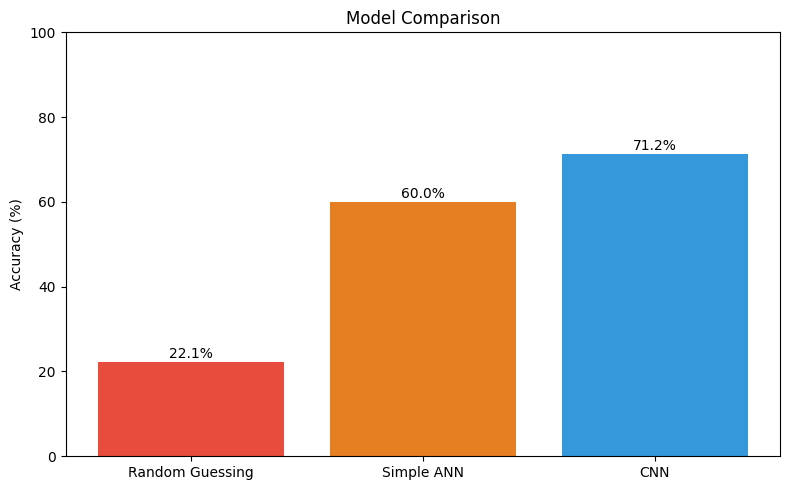

In [7]:
results = {
    "Random Guessing": eval_metrics.accuracy * 100,
    "Simple ANN": eval_metrics_ann.accuracy * 100,
    "CNN": eval_metrics_cnn.accuracy * 100
}

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(0, 100)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 1, f'{acc:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()